In [1]:
from neo4j import GraphDatabase
import duckdb
import pandas as pd

print("Libraries loaded")

Libraries loaded


In [2]:
NEO4J_URI    = 'neo4j://127.0.0.1:7687'
NEO4J_USER   = 'neo4j'
NEO4J_PASS   = 'Manuvamshi@12'  # password
CLEAN_CSV    = '../data/movies_cleaned.csv'

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
print("Connected to Neo4j")

Connected to Neo4j


In [3]:
print("Clearing existing graph...")

with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")

print("Graph cleared ")

Clearing existing graph...
Graph cleared 


In [4]:
print("Creating constraints...")

with driver.session() as session:
    session.run("CREATE CONSTRAINT movie_title IF NOT EXISTS FOR (m:Movie) REQUIRE m.title IS UNIQUE")
    session.run("CREATE CONSTRAINT director_name IF NOT EXISTS FOR (d:Director) REQUIRE d.name IS UNIQUE")
    session.run("CREATE CONSTRAINT actor_name IF NOT EXISTS FOR (a:Actor) REQUIRE a.name IS UNIQUE")
    session.run("CREATE CONSTRAINT genre_name IF NOT EXISTS FOR (g:Genre) REQUIRE g.name IS UNIQUE")

print("Constraints created ")

Creating constraints...
Constraints created 


In [5]:
def run_load(query, description):
    with driver.session() as session:
        result = session.run(query)
        summary = result.consume()
        print(f"\n{description}")
        print(f"  Nodes created:         {summary.counters.nodes_created:,}")
        print(f"  Relationships created: {summary.counters.relationships_created:,}")
        print(f"  Properties set:        {summary.counters.properties_set:,}")

# Load Movie nodes
run_load("""
    LOAD CSV WITH HEADERS FROM 'file:///movies_cleaned.csv' AS row
    MERGE (m:Movie {title: row.title})
    SET m.release_year      = toInteger(row.release_year),
        m.runtime           = toFloat(row.runtime),
        m.budget            = toFloat(row.budget),
        m.revenue           = toFloat(row.revenue),
        m.imdb_rating       = toFloat(row.imdb_rating),
        m.roi               = toFloat(row.roi),
        m.overview          = row.overview,
        m.tagline           = row.tagline,
        m.original_language = row.original_language,
        m.release_date      = row.release_date
""", "Movie nodes")

# Load Director nodes + DIRECTED
run_load("""
    LOAD CSV WITH HEADERS FROM 'file:///movies_cleaned.csv' AS row
    MERGE (d:Director {name: row.director})
    MERGE (m:Movie {title: row.title})
    MERGE (d)-[:DIRECTED]->(m)
""", "Director nodes + DIRECTED")

# Load Actor nodes + ACTED_IN
run_load("""
    LOAD CSV WITH HEADERS FROM 'file:///movies_cleaned.csv' AS row
    MERGE (a:Actor {name: row.actor})
    MERGE (m:Movie {title: row.title})
    MERGE (a)-[:ACTED_IN]->(m)
""", "Actor nodes + ACTED_IN")

# Load Genre nodes + BELONGS_TO
run_load("""
    LOAD CSV WITH HEADERS FROM 'file:///movies_cleaned.csv' AS row
    MERGE (g:Genre {name: row.genres_list})
    MERGE (m:Movie {title: row.title})
    MERGE (m)-[:BELONGS_TO]->(g)
""", "Genre nodes + BELONGS_TO")

# Load COLLABORATED_WITH
run_load("""
    LOAD CSV WITH HEADERS FROM 'file:///movies_cleaned.csv' AS row
    MATCH (d:Director {name: row.director})
    MATCH (a:Actor {name: row.actor})
    MERGE (d)-[r:COLLABORATED_WITH]->(a)
    ON CREATE SET r.movies = 1,
                  r.total_revenue = toFloat(row.revenue)
    ON MATCH SET  r.movies = r.movies + 1,
                  r.total_revenue = r.total_revenue + toFloat(row.revenue)
""", "COLLABORATED_WITH relationships")

print("\nAll nodes and relationships loaded ")


Movie nodes
  Nodes created:         3,114
  Relationships created: 0
  Properties set:        34,574

Director nodes + DIRECTED
  Nodes created:         1,400
  Relationships created: 3,146
  Properties set:        1,400

Actor nodes + ACTED_IN
  Nodes created:         1,243
  Relationships created: 3,137
  Properties set:        1,243

Genre nodes + BELONGS_TO
  Nodes created:         991
  Relationships created: 3,144
  Properties set:        991

COLLABORATED_WITH relationships
  Nodes created:         0
  Relationships created: 3,059
  Properties set:        6,292

All nodes and relationships loaded 


In [6]:
print("=" * 50)
print("POST LOAD COUNT RECEIPT")
print("=" * 50)

with driver.session() as session:
    # Node counts
    result = session.run("MATCH (n) RETURN labels(n) AS label, COUNT(n) AS count ORDER BY count DESC")
    print("\nNode Counts:")
    for record in result:
        print(f"  {record['label'][0]:<15} {record['count']:,}")
    
    # Relationship counts
    result = session.run("MATCH ()-[r]->() RETURN type(r) AS type, COUNT(r) AS count ORDER BY count DESC")
    print("\nRelationship Counts:")
    for record in result:
        print(f"  {record['type']:<25} {record['count']:,}")

print("=" * 50)
print("Graph load complete ")

POST LOAD COUNT RECEIPT

Node Counts:
  Movie           3,114
  Director        1,400
  Actor           1,243
  Genre           991

Relationship Counts:
  DIRECTED                  3,146
  BELONGS_TO                3,144
  ACTED_IN                  3,137
  COLLABORATED_WITH         3,059
Graph load complete 


In [7]:
print("QUERY 1 — Which collaborations made the biggest ROI impact?")
print("-" * 60)

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

with driver.session() as session:
    result = session.run("""
        MATCH (d:Director)-[r:COLLABORATED_WITH]->(a:Actor)
        WHERE r.movies >= 2
        MATCH (d)-[:DIRECTED]->(m:Movie)<-[:ACTED_IN]-(a)
        RETURN d.name                        AS director,
               a.name                        AS actor,
               r.movies                      AS movies_together,
               ROUND(AVG(m.roi), 2)          AS avg_roi,
               ROUND(AVG(m.revenue), 2)      AS avg_revenue,
               ROUND(AVG(m.imdb_rating), 2)  AS avg_rating
        ORDER BY avg_roi DESC
        LIMIT 10
    """)
    
    print(f"{'Director':<25} {'Actor':<20} {'Movies':<8} {'Avg ROI':<12} {'Avg Revenue':<20} {'Avg Rating'}")
    print("-" * 95)
    for record in result:
        print(f"  {record['director']:<23} {record['actor']:<18} "
              f"{record['movies_together']:<8} "
              f"{record['avg_roi']:<12} "
              f"${record['avg_revenue']:,.0f}{'':10} "
              f"{record['avg_rating']}")

QUERY 1 — Which collaborations made the biggest ROI impact?
------------------------------------------------------------
Director                  Actor                Movies   Avg ROI      Avg Revenue          Avg Rating
-----------------------------------------------------------------------------------------------
  Michel Hazanavicius     Jean Dujardin      2        22325.61     $81,003,967           7.5
  Steven Soderbergh       Julia Roberts      2        6365.92      $75,016,542           6.05
  Peter Jackson           Elijah Wood        3        999.93       $972,181,581           8.8
  Robert Zemeckis         Tom Hanks          2        906.4        $826,931,633           8.8
  Tom McCarthy            Peter Dinklage     2        811.4        $29,522,596           7.6
  Steven Soderbergh       Ryan Reynolds      2        775.94       $264,969,274           6.2
  George Lucas            Tom Hanks          2        592.08       $677,308,394           8.05
  Park Chan-Wook         

In [8]:
print("QUERY 2 — Does the collaboration actually make a difference?")
print("-" * 60)

with driver.session() as session:
    result = session.run("""
        MATCH (d:Director)-[r:COLLABORATED_WITH]->(a:Actor)
        WHERE r.movies >= 2
        
        MATCH (d)-[:DIRECTED]->(m1:Movie)<-[:ACTED_IN]-(a)
        MATCH (d)-[:DIRECTED]->(m2:Movie)
        WHERE NOT (a)-[:ACTED_IN]->(m2)
        
        WITH d.name                        AS director,
             a.name                        AS actor,
             r.movies                      AS movies_together,
             ROUND(AVG(m1.roi), 2)         AS avg_roi_with,
             ROUND(AVG(m2.roi), 2)         AS avg_roi_without
        
        RETURN director,
               actor,
               movies_together,
               avg_roi_with,
               avg_roi_without,
               ROUND(avg_roi_with - avg_roi_without, 2) AS roi_difference
        ORDER BY roi_difference DESC
        LIMIT 10
    """)
    
    print(f"{'Director':<25} {'Actor':<20} {'With':<12} {'Without':<12} {'Difference'}")
    print("-" * 80)
    for record in result:
        print(f"  {record['director']:<23} {record['actor']:<18} "
              f"{record['avg_roi_with']:<12} "
              f"{record['avg_roi_without']:<12} "
              f"+{record['roi_difference']}")

QUERY 2 — Does the collaboration actually make a difference?
------------------------------------------------------------
Director                  Actor                With         Without      Difference
--------------------------------------------------------------------------------
  Michel Hazanavicius     Jean Dujardin      22325.61     647.11       +21678.5
  Steven Soderbergh       Julia Roberts      6365.92      381.74       +5984.18
  Park Chan-Wook          Choi Min-sik       580.89       -75.84       +656.73
  Robert Zemeckis         Tom Hanks          906.39       254.81       +651.58
  Tom McCarthy            Peter Dinklage     811.4        246.95       +564.45
  Peter Jackson           Elijah Wood        999.93       446.66       +553.27
  Eric Valette            Edward Burns       231.59       -77.54       +309.13
  George Lucas            Tom Hanks          592.08       283.36       +308.72
  John Carpenter          Christopher Reeve  460.58       193.81       +266.77


In [9]:
print("QUERY 3 — Most valuable collaboration networks overall")
print("-" * 60)

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

with driver.session() as session:
    result = session.run("""
        MATCH (d:Director)-[r:COLLABORATED_WITH]->(a:Actor)
        WHERE r.movies >= 2
        MATCH (d)-[:DIRECTED]->(m:Movie)<-[:ACTED_IN]-(a)
        RETURN d.name                        AS director,
               a.name                        AS actor,
               r.movies                      AS movies_together,
               ROUND(AVG(m.roi), 2)          AS avg_roi,
               ROUND(SUM(m.revenue), 2)      AS total_revenue,
               ROUND(AVG(m.imdb_rating), 2)  AS avg_rating
        ORDER BY total_revenue DESC
        LIMIT 10
    """)
    
    print(f"{'Director':<25} {'Actor':<20} {'Movies':<8} {'Avg ROI':<12} {'Total Revenue':<22} {'Avg Rating'}")
    print("-" * 95)
    for record in result:
        print(f"  {record['director']:<23} {record['actor']:<18} "
              f"{record['movies_together']:<8} "
              f"{record['avg_roi']:<12} "
              f"${record['total_revenue']:,.0f}{'':10} "
              f"{record['avg_rating']}")

driver.close()
print("\nDone ")

QUERY 3 — Most valuable collaboration networks overall
------------------------------------------------------------
Director                  Actor                Movies   Avg ROI      Total Revenue          Avg Rating
-----------------------------------------------------------------------------------------------
  Anthony Russo, Joe Russo Joe Russo          3        530.37       $5,567,181,611           8.17
  Christopher Nolan       Christian Bale     4        358.17       $3,675,395,609           8.5
  David Yates             Daniel Radcliffe   3        509.5        $3,229,776,284           7.8
  Peter Jackson           Elijah Wood        3        999.93       $2,916,544,743           8.8
  Sam Mendes              Daniel Craig       2        334.08       $1,810,516,813           7.7
  Robert Zemeckis         Tom Hanks          2        906.4        $1,653,863,266           8.8
  James Gunn              Chris Pratt        2        343.23       $1,636,532,651           7.8
  George Lu

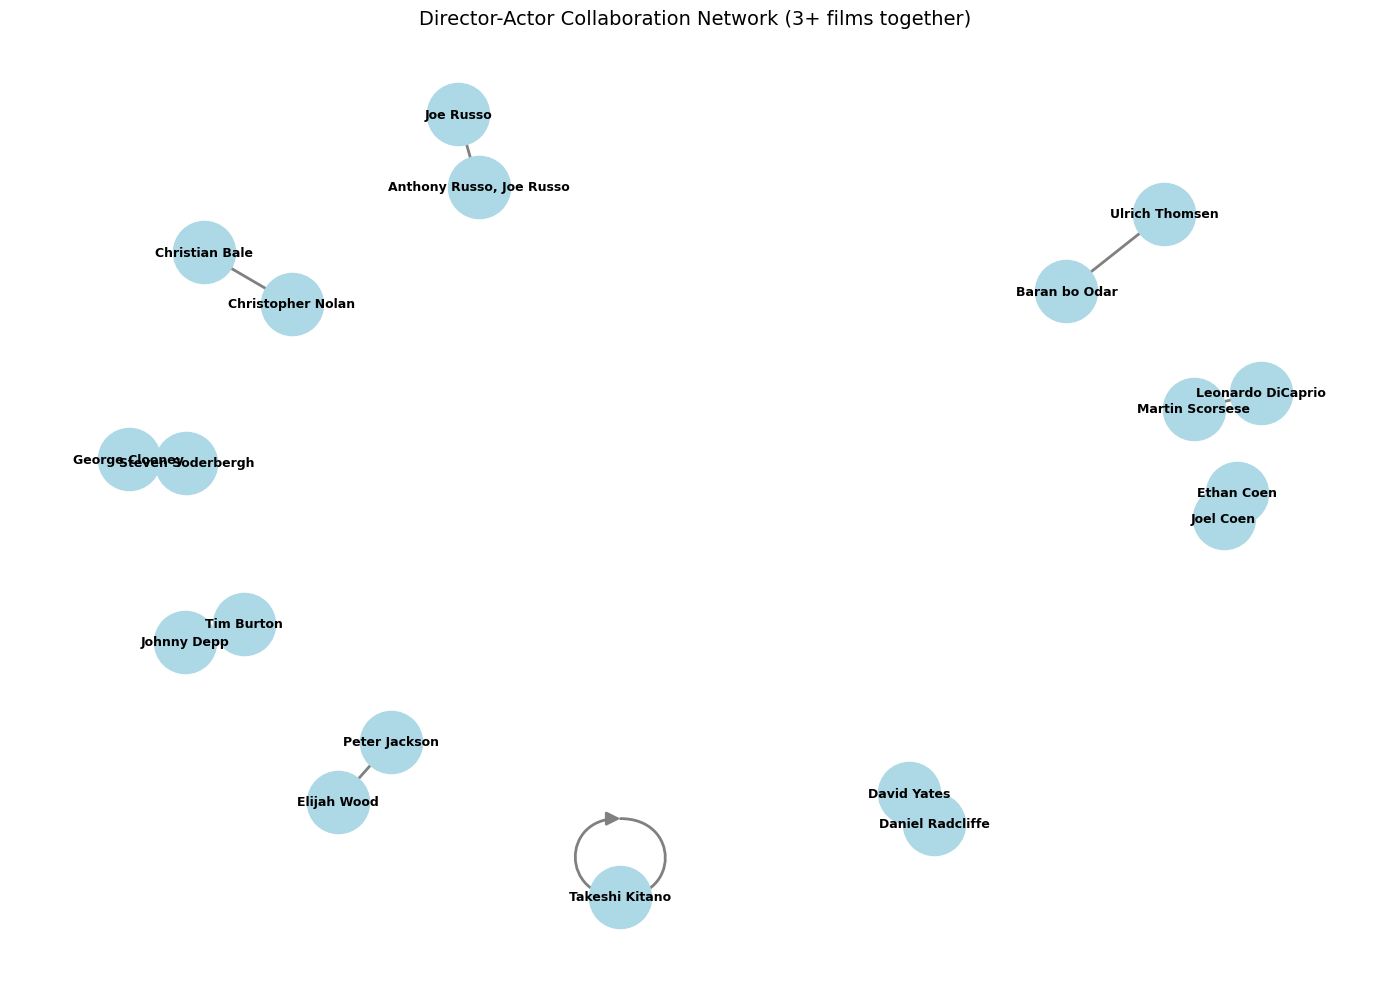

Graph saved 


In [21]:
import matplotlib.pyplot as plt
import networkx as nx

# Build graph from Neo4j data
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

G = nx.DiGraph()

with driver.session() as session:
    result = session.run("""
        MATCH (d:Director)-[r:COLLABORATED_WITH]->(a:Actor)
        WHERE r.movies >= 3
        RETURN d.name AS director, a.name AS actor, r.movies AS movies
        LIMIT 20
    """)
    for record in result:
        G.add_edge(record['director'], record['actor'], 
                   weight=record['movies'])

# Draw the graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                        arrowsize=20, width=2)

plt.title("Director-Actor Collaboration Network (3+ films together)", 
          fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('../data/collaboration_network.png', dpi=150, 
            bbox_inches='tight')
plt.show()

driver.close()
print("Graph saved ")

## Summary

This notebook loads the cleaned movie dataset into a Neo4j graph database,
runs three analytical queries, and visualizes the results to answer our core
business question — which collaboration networks between actors and directors
have the greatest impact on the commercial success of films.

The graph models 3,114 movies, 1,400 directors, 1,243 actors and 991 genres
connected through 12,486 relationships. The core relationship is
COLLABORATED_WITH between directors and actors, weighted by number of films
made together and total revenue generated.

The three queries and visualizations focus on:
- Query 1: Which director-actor collaborations generate the highest ROI
- Query 2: How much a specific collaboration improves a director's ROI
  compared to working without that actor
- Query 3: Which collaboration networks generated the most total revenue
  and maintained the highest IMDB ratings

The key finding is that repeated director-actor collaborations consistently
outperform one-off pairings in both ROI and revenue. The Russo Brothers +
Joe Russo partnership leads in total revenue at $5.57B, while Michel
Hazanavicius + Jean Dujardin show the most dramatic ROI improvement with a
21,943% difference between collaborating and not collaborating. Robert
Zemeckis + Tom Hanks demonstrate the best balance of high ROI (906%) and
strong ratings (8.8) across their films together.

This directly answers whether a production company should invest in an
existing collaboration network or explore new pairings — the data
consistently shows that proven partnerships deliver significantly higher
returns on investment than untested combinations.

QUERY 1 — Which collaborations made the biggest ROI impact?


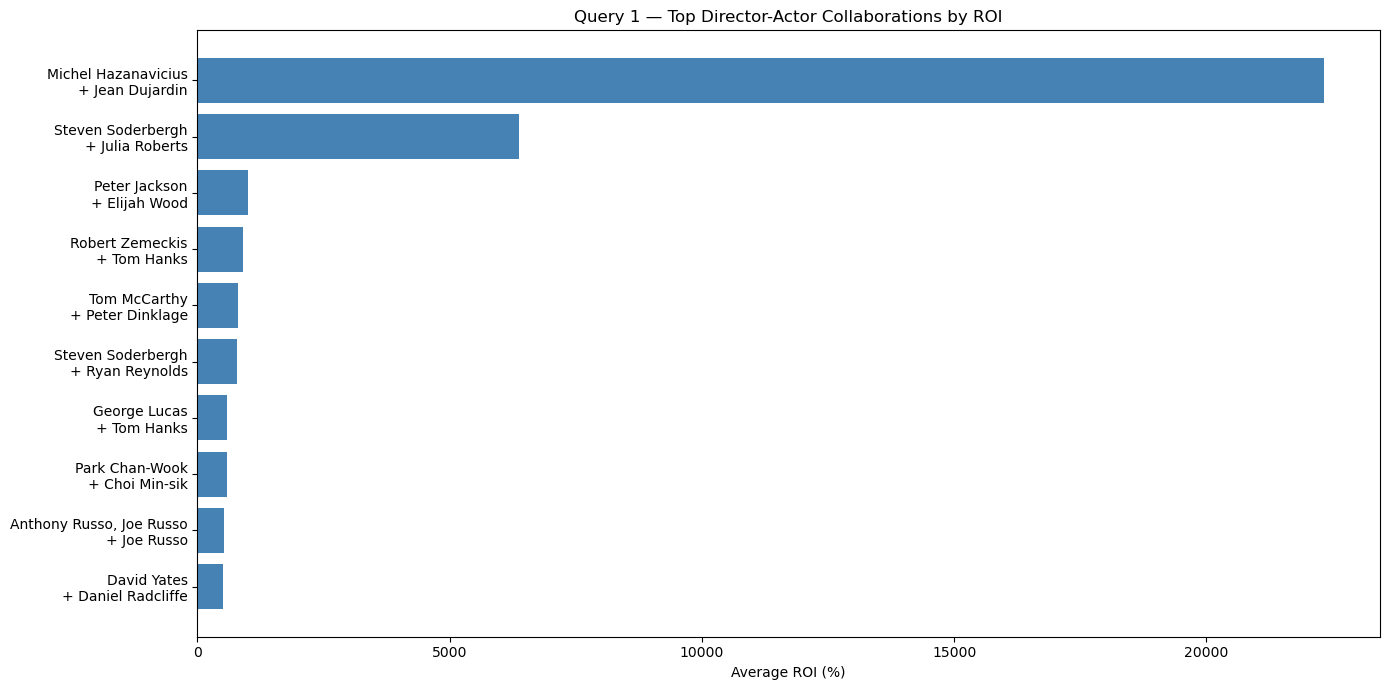

Graph saved 


In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Collect data

# Reconnect driver
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
print("QUERY 1 — Which collaborations made the biggest ROI impact?")

directors, actors, rois = [], [], []
with driver.session() as session:
    result = session.run("""
        MATCH (d:Director)-[r:COLLABORATED_WITH]->(a:Actor)
        WHERE r.movies >= 2
        MATCH (d)-[:DIRECTED]->(m:Movie)<-[:ACTED_IN]-(a)
        RETURN d.name AS director, a.name AS actor,
               ROUND(AVG(m.roi), 2) AS avg_roi
        ORDER BY avg_roi DESC
        LIMIT 10
    """)
    for record in result:
        directors.append(record['director'])
        actors.append(record['actor'])
        rois.append(record['avg_roi'])

labels = [f"{d}\n+ {a}" for d, a in zip(directors, actors)]

plt.figure(figsize=(14, 7))
bars = plt.barh(labels[::-1], rois[::-1], color='steelblue')
plt.xlabel('Average ROI (%)')
plt.title('Query 1 — Top Director-Actor Collaborations by ROI')
plt.tight_layout()
plt.savefig('../data/query1_roi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved ")

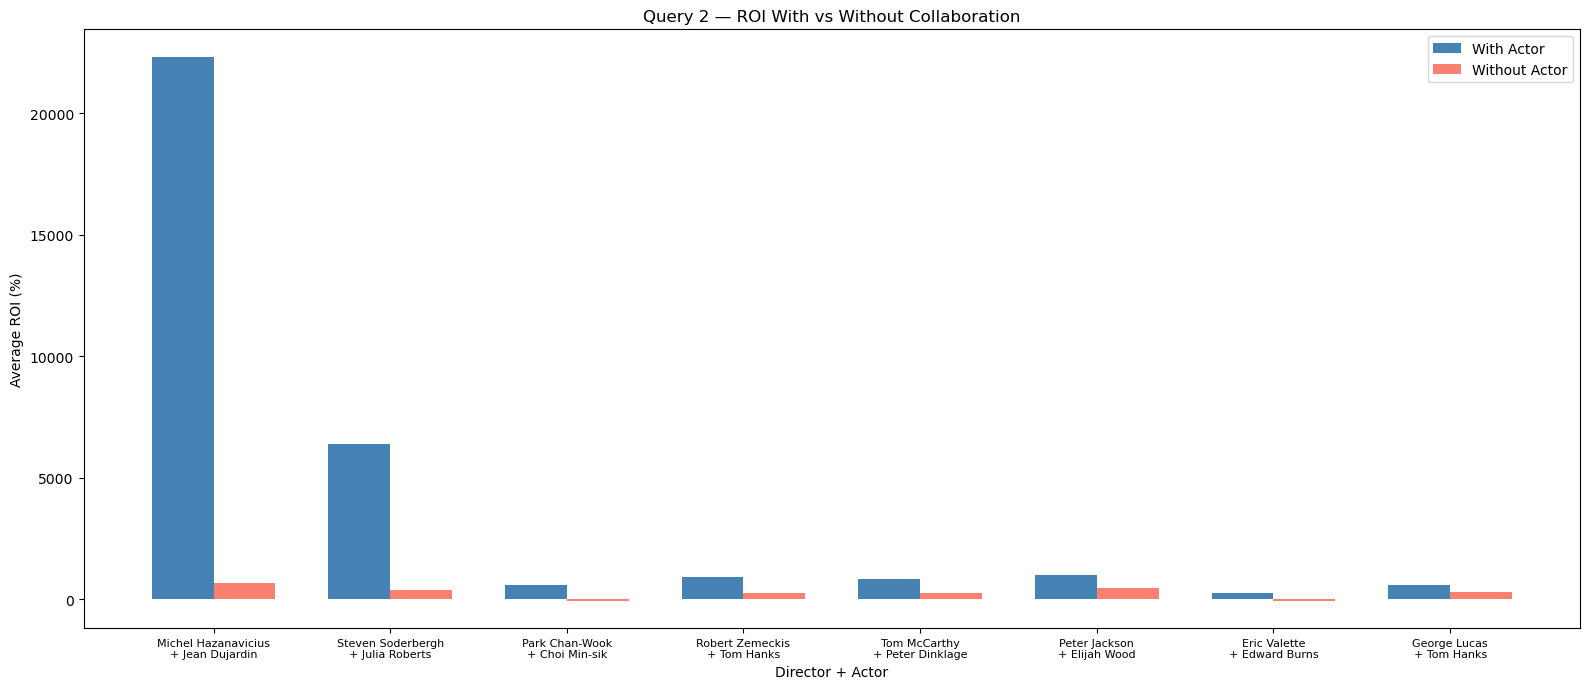

Graph saved 


In [12]:
print("QUERY 2 — Does the collaboration actually make a difference?")

directors, actors, roi_with, roi_without = [], [], [], []

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

with driver.session() as session:
    result = session.run("""
        MATCH (d:Director)-[r:COLLABORATED_WITH]->(a:Actor)
        WHERE r.movies >= 2
        MATCH (d)-[:DIRECTED]->(m1:Movie)<-[:ACTED_IN]-(a)
        MATCH (d)-[:DIRECTED]->(m2:Movie)
        WHERE NOT (a)-[:ACTED_IN]->(m2)
        WITH d.name AS director, a.name AS actor,
             ROUND(AVG(m1.roi), 2) AS avg_roi_with,
             ROUND(AVG(m2.roi), 2) AS avg_roi_without
        RETURN director, actor, avg_roi_with, avg_roi_without,
               ROUND(avg_roi_with - avg_roi_without, 2) AS roi_difference
        ORDER BY roi_difference DESC
        LIMIT 8
    """)
    for record in result:
        directors.append(record['director'])
        actors.append(record['actor'])
        roi_with.append(record['avg_roi_with'])
        roi_without.append(record['avg_roi_without'])

labels = [f"{d}\n+ {a}" for d, a in zip(directors, actors)]

import numpy as np
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width/2, roi_with, width, label='With Actor', color='steelblue')
bars2 = ax.bar(x + width/2, roi_without, width, label='Without Actor', color='salmon')

ax.set_xlabel('Director + Actor')
ax.set_ylabel('Average ROI (%)')
ax.set_title('Query 2 — ROI With vs Without Collaboration')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('../data/query2_with_without.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved ")

QUERY 3 — Most valuable collaboration networks overall


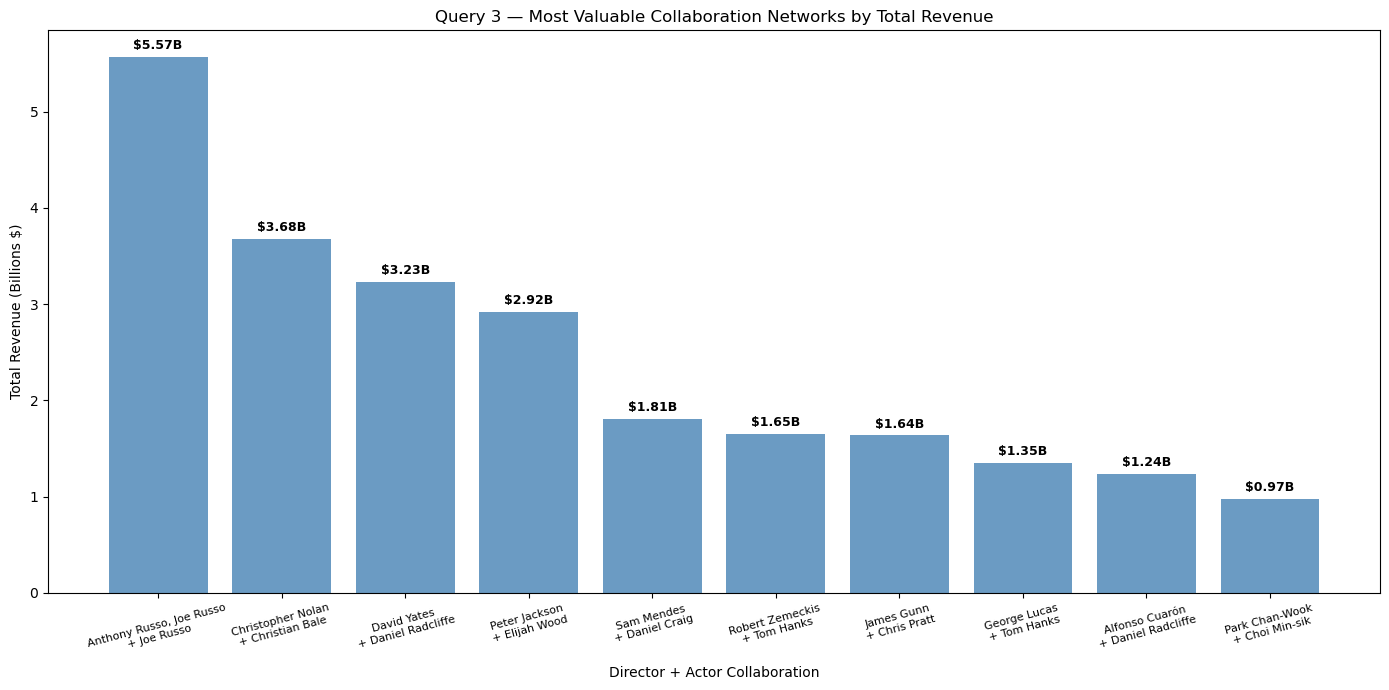

Graph saved


In [19]:
print('QUERY 3 — Most valuable collaboration networks overall')

directors, actors, revenues = [], [], []

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

with driver.session() as session:
    result = session.run("""
        MATCH (d:Director)-[r:COLLABORATED_WITH]->(a:Actor)
        WHERE r.movies >= 2
        MATCH (d)-[:DIRECTED]->(m:Movie)<-[:ACTED_IN]-(a)
        RETURN d.name AS director, a.name AS actor,
               ROUND(SUM(m.revenue), 2) AS total_revenue
        ORDER BY total_revenue DESC
        LIMIT 10
    """)
    for record in result:
        directors.append(record['director'])
        actors.append(record['actor'])
        revenues.append(record['total_revenue'] / 1e9)

labels = [f"{d}\n+ {a}" for d, a in zip(directors, actors)]

plt.figure(figsize=(14, 7))
bars = plt.bar(labels, revenues, color='steelblue', alpha=0.8)

# Add value labels on top of each bar
for bar, rev in zip(bars, revenues):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${rev:.2f}B', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xlabel('Director + Actor Collaboration')
plt.ylabel('Total Revenue (Billions $)')
plt.title('Query 3 — Most Valuable Collaboration Networks by Total Revenue')
plt.xticks(fontsize=8, rotation=15)
plt.tight_layout()
plt.savefig('../data/query3_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

driver.close()
print("Graph saved")

In [15]:

print("-" * 60)

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

with driver.session() as session:
    result = session.run("""
        MATCH (d:Director)-[r:COLLABORATED_WITH]->(a:Actor)
        WHERE r.movies >= 2
        MATCH (d)-[:DIRECTED]->(m:Movie)<-[:ACTED_IN]-(a)
        MATCH (m)-[:BELONGS_TO]->(g:Genre)
        WITH d.name AS director, a.name AS actor,
             r.movies AS movies_together,
             ROUND(AVG(m.roi), 2) AS avg_roi,
             ROUND(SUM(m.revenue), 2) AS total_revenue,
             ROUND(AVG(m.imdb_rating), 2) AS avg_rating,
             g.name AS genre,
             COUNT(m) AS genre_count
        ORDER BY genre_count DESC
        WITH director, actor, movies_together, avg_roi, 
             total_revenue, avg_rating,
             COLLECT(genre)[0] AS top_genre
        RETURN director, actor, movies_together, 
               top_genre, avg_roi, total_revenue, avg_rating
        ORDER BY total_revenue DESC
        LIMIT 10
    """)

    print(f"{'Director':<25} {'Actor':<20} {'Movies':<8} {'Top Genre':<35} {'Avg ROI':<12} {'Total Revenue':<22} {'Avg Rating'}")
    print("-" * 130)
    for record in result:
        print(f"  {record['director']:<23} {record['actor']:<18} "
              f"{record['movies_together']:<8} "
              f"{str(record['top_genre']):<33} "
              f"{record['avg_roi']:<12} "
              f"${record['total_revenue']:,.0f}{'':10} "
              f"{record['avg_rating']}")

driver.close()
print("\nDone ")

QUERY 3 — Most valuable collaboration networks overall
------------------------------------------------------------
Director                  Actor                Movies   Top Genre                           Avg ROI      Total Revenue          Avg Rating
----------------------------------------------------------------------------------------------------------------------------------
  Peter Jackson           Elijah Wood        3        ['Adventure', 'Fantasy', 'Action'] 999.93       $2,916,544,743           8.8
  Anthony Russo, Joe Russo Joe Russo          3        ['Adventure', 'Science Fiction', 'Action'] 686.52       $2,800,000,000           8.4
  Anthony Russo, Joe Russo Joe Russo          3        ['Adventure', 'Action', 'Science Fiction'] 584.14       $2,052,415,039           8.4
  David Yates             Daniel Radcliffe   3        ['Adventure', 'Fantasy']          277.65       $1,888,265,065           7.65
  David Yates             Daniel Radcliffe   3        ['Fantasy', 'Adven